# Simulate discrete events

In [1]:
import warnings
from copy import deepcopy
from tqdm import trange
from math import acos, cos, exp, pi, sin, sqrt, tan, atan, degrees
from statistics import geometric_mean

import matplotlib.pyplot as plt
import numpy as np
from colorspacious import cspace_convert
from ipywidgets import Button, HBox, IntSlider, FloatText, FloatSlider
from matplotlib import rcParams
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.markers import MarkerStyle
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, Normalize, to_rgb
from matplotlib.patches import Arc, Ellipse, FancyArrow
from numpy import (
    any,
    arccos,
    arctan2,
    arange,
    array,
    asarray,
    clip,
    column_stack,
    concatenate,
    deg2rad,
    degrees,
    empty_like,
    floor,
    round,
    hstack,
    linspace,
    unravel_index,
    newaxis,
    radians,
    sign,
)
from numpy.random import default_rng
from scipy.stats import gamma, kstest, ks_2samp, lognorm, probplot, shapiro, weibull_min, linregress
from scipy.optimize import minimize_scalar, root_scalar
from numpy.typing import ArrayLike
from typing import Any, Sequence, cast

In [2]:
from pNeuma_simulator import params

In [3]:
warnings.filterwarnings("ignore")
rcParams["animation.embed_limit"] = 2**128
rcParams.update(
    {
        "pdf.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
        "mathtext.fontset": "stix",
        "mathtext.default": "regular",
        "font.size": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.25,
        "xtick.major.width": 0.25,
        "ytick.major.width": 0.25,
        "xtick.minor.width": 0.25,
        "ytick.minor.width": 0.25,
    }
)
# LaTeX packages
plt.rc("text", usetex=False)
plt.rc(
    "text.latex",
    preamble=r"\usepackage{amsmath}",
)
plt.rc("text.latex", preamble=r"\usepackage{gensymb}")
dark_blue = "#1964B0"
dark_teal = "#008A69"
vermilion = "#DB5829"
orange = "#F4A637"
maroon = "#894B45"
dark_purple = "#882D71"
light_purple = "#D2BBD7"
grey = "#DEDEDE"
yellow = "#E9DC6D"
# RYG traffic colors
RAL_3020 = "#B81D13"
RAL_1023 = "#EFB700"
RAL_6024 = "#008450"

In [4]:
def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)  # type: ignore
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [5]:
%matplotlib inline
# Hex color stops: red → yellow → green
hex_colors = [RAL_3020, yellow, RAL_6024]
# Convert hex → RGB (0–1)
rgb = array([to_rgb(h) for h in hex_colors])
# Convert to Lab
lab = cspace_convert(rgb, "sRGB1", "CIELab")
# Interpolate smoothly in Lab
steps = 256
t = linspace(0, 1, steps)
# Quadratic Bézier interpolation between 3 colors
lab_interp = array([(1 - tt) ** 2 * lab[0] + 2 * (1 - tt) * tt * lab[1] + tt**2 * lab[2] for tt in t])
# Convert back to RGB
rgb_interp = cspace_convert(lab_interp, "CIELab", "sRGB1")
rgb_interp = clip(rgb_interp, 0, 1)
# Build colormap
cmap = ListedColormap(rgb_interp, name="RYG_Lab")

In [6]:
def newell_surface(velocities, spacings, dt):
    """
    Compute the proper discrete Newell surface for ordered vehicles on a periodic road.

    velocities: [T, N] array of vehicle velocities
    spacings: [T, N] array of vehicle spacings
    dt: time step
    """

    # Step 1: cumulative flow along each trajectory
    cumulative_flow = np.cumsum((velocities / spacings) * dt, axis=0)

    # Step 2: proper Newell surface
    N = cumulative_flow

    return N

In [7]:
def interface_width_series(H):
    H_mean = np.mean(H, axis=1, keepdims=True)  # mean over spatial indices
    W_series = np.sqrt(np.mean((H - H_mean) ** 2, axis=1))
    return W_series

In [8]:
from palettable.colorbrewer.diverging import RdYlGn_11  # type: ignore
from palettable.colorbrewer.diverging import Spectral_8  # type: ignore
from palettable.colorbrewer.diverging import Spectral_8_r  # type: ignore
from palettable.colorbrewer.sequential import GnBu_9  # type: ignore

cmap_seq = GnBu_9.mpl_colormap
cmap = Spectral_8.mpl_colormap  # type: ignore
cmap = RdYlGn_11.mpl_colormap

In [9]:
import pandas as pd
import os
import glob

## Dome data

In [10]:
from scipy.signal import savgol_filter

road_length = 2 * np.pi * 50
session_dir = "./input/dome_data/2534"
session_dir = "./input/dome_data/2634"
session_dir = "./input/dome_data/1835"
session_dir = "./input/dome_data/2934"

angles_in_degrees = True

# --------------------------------------------------
# 1) read all trajectory files
# --------------------------------------------------
files = sorted(glob.glob(os.path.join(session_dir, "*.txt")))
if not files:
    raise FileNotFoundError(f"No .txt files found in {session_dir}")

traj_list = []
veh_ids = []

for file_path in files:
    veh_id = os.path.splitext(os.path.basename(file_path))[0]  # '00', '01', ...
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        names=["angle", "time"],
        engine="python",
    ).sort_values("time")

    traj_list.append(df)
    veh_ids.append(int(veh_id))  # store as integer

veh_ids = np.array(veh_ids)

# --------------------------------------------------
# 2) common time grid = intersection of all time ranges
# --------------------------------------------------
t_min = max(df["time"].min() for df in traj_list)
t_max = min(df["time"].max() for df in traj_list)

all_dts = np.concatenate([np.diff(df["time"].to_numpy()) for df in traj_list])
dt = np.median(all_dts)

timestamps = np.arange(t_min, t_max + 0.5 * dt, dt)

# --------------------------------------------------
# 3) build positions and velocities
# --------------------------------------------------
n_times = len(timestamps)
n_vehicles = len(traj_list)

positions = np.zeros((n_times, n_vehicles))
velocities = np.zeros((n_times, n_vehicles))

window = 9
poly = 2

for j, df in enumerate(traj_list):
    t = df["time"].to_numpy()
    a = df["angle"].to_numpy()

    theta = np.deg2rad(a) if angles_in_degrees else a.copy()

    # unwrap angle over time
    theta_unwrapped = np.unwrap(theta)

    # interpolate unwrapped angle onto common time grid
    theta_interp = np.interp(timestamps, t, theta_unwrapped)

    # choose valid odd window length
    w = min(window, len(theta_interp))
    if w % 2 == 0:
        w -= 1

    # smooth and differentiate
    if w >= 3:
        p = min(poly, w - 1)
        theta_smooth = savgol_filter(theta_interp, window_length=w, polyorder=p)
        omega = savgol_filter(
            theta_interp,
            window_length=w,
            polyorder=p,
            deriv=1,
            delta=dt,  # type: ignore
        )
    else:
        theta_smooth = theta_interp
        omega = np.gradient(theta_interp, dt)

    # wrapped ring position in meters
    positions[:, j] = np.mod(theta_smooth, 2 * np.pi) * road_length / (2 * np.pi)
    velocities[:, j] = omega * road_length / (2 * np.pi)

# optional, but usually better to remove unless you really want it
# velocities[0, :] = 0.0

# --------------------------------------------------
# 4) order vehicles by dataset convention
# largest index = first car
# --------------------------------------------------
id_order = np.argsort(veh_ids)  # [::-1]

positions = positions[:, id_order]
velocities = velocities[:, id_order]
veh_ids = veh_ids[id_order]

# --------------------------------------------------
# 5) spacing matrix
# spacing to the next car in dataset order
# --------------------------------------------------
spacings = (np.roll(positions, -1, axis=1) - positions) % road_length

print("timestamps shape:", timestamps.shape)
print("positions shape:", positions.shape)
print("velocities shape:", velocities.shape)
print("spacings shape:", spacings.shape)
print("vehicle order:", veh_ids)

# sanity check: spacings should sum to road length at each time
print("mean sum of spacings:", np.mean(np.sum(spacings, axis=1)))
print("road length:", road_length)

timestamps shape: (1313,)
positions shape: (1313, 34)
velocities shape: (1313, 34)
spacings shape: (1313, 34)
vehicle order: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33]
mean sum of spacings: 314.1592653589793
road length: 314.1592653589793


In [11]:
from matplotlib.ticker import FuncFormatter

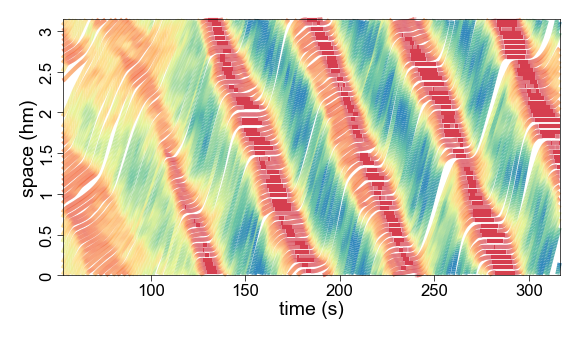

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7 * params.cm, 4 * params.cm), dpi=200)

for j in range(positions.shape[1]):
    t_vals = []
    x_vals = []
    v_vals = []

    prev_x = None
    for t_i, x_i, v_i in zip(timestamps, positions[:, j], velocities[:, j]):
        # break the line when the circular position wraps around
        if prev_x is not None and abs(x_i - prev_x) > 0.5 * road_length:
            t_vals.append(t_i)
            x_vals.append(np.nan)
            v_vals.append(np.nan)

        t_vals.append(t_i)
        x_vals.append(x_i)
        v_vals.append(v_i)
        prev_x = x_i

    t_vals = np.asarray(t_vals, dtype=float)
    x_vals = np.asarray(x_vals, dtype=float)
    v_vals = np.asarray(v_vals, dtype=float)

    colored_line(
        t_vals,
        x_vals,
        v_vals,
        ax=ax,
        cmap=Spectral_8.mpl_colormap,
        clip_on=False,
        zorder=-1,
    )
ax.set_ylabel("space (hm)", labelpad=0.5)
ax.set_xlabel("time (s)", labelpad=0.5)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/100:g}"))
#ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{y/60:g}"))
ax.tick_params(axis="y", length=2, pad=1, labelrotation=90)
ax.tick_params(axis="x", length=2, pad=1)
plt.setp(ax.get_yticklabels(), ha="right", va="center")
plt.tight_layout(pad=0)
ax.set_xlim(timestamps[0], timestamps[-1])
ax.set_ylim(0, road_length)

plt.show()

In [13]:
def eulerian_surface_from_passages(positions, L, dx=7.0):
    T, N = positions.shape
    M = int(np.ceil(L / dx))

    h = np.zeros((T, M), dtype=np.int32)

    prev_cells = np.floor(np.mod(positions[0], L) / dx).astype(int) % M

    for t in range(1, T):
        curr_cells = np.floor(np.mod(positions[t], L) / dx).astype(int) % M

        h[t] = h[t - 1]

        for j in range(N):
            c0 = prev_cells[j]
            c1 = curr_cells[j]
            crossed = (c1 - c0) % M

            for k in range(1, crossed + 1):
                h[t, (c0 + k) % M] += 1

        prev_cells = curr_cells

    x = (np.arange(M) + 0.5) * dx
    x = np.minimum(x, L - 0.5 * dx)
    return x, h

In [14]:
_, h_euler = eulerian_surface_from_passages(
    positions=positions,
    # timestamps=timestamps,
    L=road_length,
    dx=2 * 3.885,
)

In [15]:
# _ = plt.imshow(h_euler, aspect="auto", cmap=Spectral_8.mpl_colormap, origin="lower")

In [16]:
N = h_euler

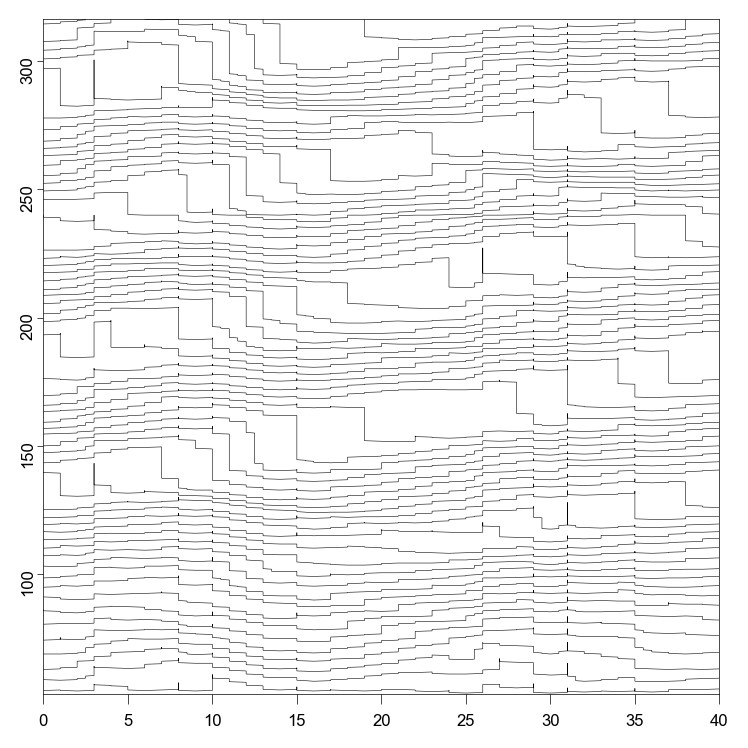

In [17]:
fig, ax = plt.subplots(figsize=(9 * params.cm, 9 * params.cm), dpi=200)

# Assuming N_fluct is a 2D array
# Create coordinate grids for plotting
y = np.arange(N.shape[0])
x = np.arange(N.shape[1])
x = np.arange(N.shape[1])[::-1]
X, Y = np.meshgrid(x, y)

# Plot black contours
# Number of contour levels you want
num_contours = 60  # <-- change this to control number of contours

# Plot contours
contours = ax.contour(
    X,
    Y * np.diff(t_vals)[0] + t_vals[0],
    N,  # your array (negated if needed)
    levels=num_contours,  # number of contour levels
    colors="black",  # black lines
    linewidths=0.2,  # line width
)
ax.tick_params(axis="y", length=2, pad=1, labelrotation=90)
# ax.set_title("Contour Plot of N_fluct")
## Remove all ticks and numbers
# ax.set_xticks([])  # remove x-axis ticks
# ax.set_yticks([])  # remove y-axis ticks
# ax.set_xticklabels([])  # remove x-axis labels
# ax.set_yticklabels([])  # remove y-axis labels
# ax.invert_xaxis()
plt.tight_layout(pad=0)
plt.show()

In [18]:
W = interface_width_series(N)

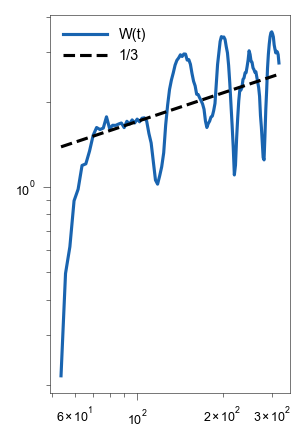

In [27]:
# Assume W_series is already computed and has shape (T,)

start = 2
fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=150)
names = []
ax.set_aspect("equal")
# for W, timestamps, letter in zip(l_W, l_timestamps, letters):
W_late = W[start:]  # take late-time part
t = timestamps[start:]  # np.arange(start, start + len(W_late))  # corresponding time steps
skip = 10
plt.loglog(t[::skip], W_late[::skip], label=f"W(t)", c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t))
ref_line = np.exp(logA) * t ** (1 / 3)
plt.loglog(t, ref_line, "--", label="1/3", c="k")


ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

In [20]:
root_dir = "./input/dome_data"
# road_length = 2 * np.pi
angles_in_degrees = True

all_sessions = {}
l_W = []
l_timestamps = []
l_names = []
session_dirs = sorted(d for d in glob.glob(os.path.join(root_dir, "*")) if os.path.isdir(d))

if not session_dirs:
    raise FileNotFoundError(f"No session folders found in {root_dir}")

for session_dir in session_dirs:
    session_name = os.path.basename(session_dir)
    if session_name[-2:] == "34":

        files = sorted(glob.glob(os.path.join(session_dir, "*.txt")))
        if not files:
            print(f"Skipping {session_name}: no .txt files found")
            continue

        traj_list = []
        veh_ids = []

        for file_path in files:
            veh_id = os.path.splitext(os.path.basename(file_path))[0]

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                names=["angle", "time"],
                engine="python",
            ).sort_values("time")

            if len(df) < 2:
                continue

            traj_list.append(df)
            veh_ids.append(veh_id)

        if not traj_list:
            print(f"Skipping {session_name}: no valid trajectories")
            continue

        # common time grid = intersection of all time ranges
        t_min = max(df["time"].min() for df in traj_list)
        t_max = min(df["time"].max() for df in traj_list)

        if t_max <= t_min:
            print(f"Skipping {session_name}: invalid common time range")
            continue

        dt = np.median(np.diff(traj_list[0]["time"].to_numpy()))
        timestamps = np.arange(t_min, t_max + 0.5 * dt, dt)

        n_times = len(timestamps)
        n_vehicles = len(traj_list)

        positions = np.zeros((n_times, n_vehicles))
        velocities = np.zeros((n_times, n_vehicles))

        window = 9
        poly = 2

        for j, df in enumerate(traj_list):
            t = df["time"].to_numpy()
            a = df["angle"].to_numpy()

            theta = np.deg2rad(a) if angles_in_degrees else a.copy()
            theta_unwrapped = np.unwrap(theta)
            theta_interp = np.interp(timestamps, t, theta_unwrapped)

            w = min(window, len(theta_interp) if len(theta_interp) % 2 == 1 else len(theta_interp) - 1)

            if w >= 3:
                p = min(poly, w - 1)
                theta_smooth = savgol_filter(theta_interp, window_length=w, polyorder=p)
                omega = savgol_filter(
                    theta_interp,
                    window_length=w,
                    polyorder=p,
                    deriv=1,
                    delta=dt,  # type: ignore
                )
            else:
                theta_smooth = theta_interp
                omega = np.gradient(theta_interp, dt)

            positions[:, j] = (theta_smooth % (2 * np.pi)) / (2 * np.pi) * road_length
            velocities[:, j] = omega * road_length / (2 * np.pi)

        velocities[0, :] = 0.0

        id_order = np.argsort(positions[0])
        positions = positions[:, id_order]
        velocities = velocities[:, id_order]
        veh_ids = np.array(veh_ids)[id_order]

        spacings = (np.roll(positions, -1, axis=1) - positions) % road_length

        all_sessions[session_name] = {
            "timestamps": timestamps,
            "positions": positions,
            "velocities": velocities,
            "spacings": spacings,
            "veh_ids": veh_ids,
        }

        print(
            f"{session_name}: "
            f"times={timestamps.shape}, "
            f"positions={positions.shape}, "
            f"velocities={velocities.shape}, "
            f"spacings={spacings.shape}"
            f"min={np.min(spacings)}",
            f"max={np.max(spacings)}",
        )
        # N = newell_surface(velocities, spacings, dt)
        _, N = eulerian_surface_from_passages(
            positions=positions,
            L=road_length,
            dx=1,
        )
        W = interface_width_series(N)
        l_timestamps.append(timestamps)
        l_W.append(W)
        l_names.append(session_name)

2534: times=(2887,), positions=(2887, 34), velocities=(2887, 34), spacings=(2887, 34)min=4.498891798975535 max=25.74617634670134
2634: times=(3542,), positions=(3542, 34), velocities=(3542, 34), spacings=(3542, 34)min=3.659898707928704 max=66.4647443402888
2934: times=(1313,), positions=(1313, 34), velocities=(1313, 34), spacings=(1313, 34)min=3.9895953462702067 max=48.798432805066454


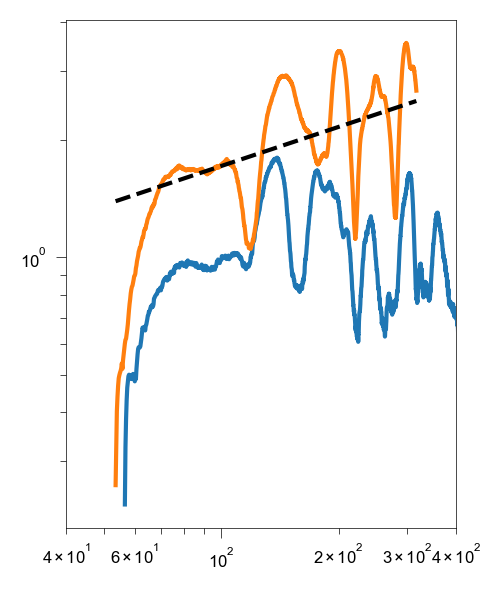

In [21]:
# Assume W_series is already computed and has shape (T,)

start = 1
fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
names = []
ax.set_aspect("equal")
for W, timestamps, letter in zip([l_W[0], l_W[2]], [l_timestamps[0], l_timestamps[2]], [l_names[0], l_names[2]]):
    W_late = W[start:]  # take late-time part
    t = timestamps[start:]  # np.arange(start, start + len(W_late))  # corresponding time steps

    plt.loglog(t, W_late, label=f"W{letter}(t)")  # , c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t))
ref_line = np.exp(logA) * t ** (1 / 3)
plt.loglog(t, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )
#
# ax.legend(
#    frameon=False,
#    handlelength=3,
#    fontsize=7,
#    loc=0,
# )
ax.set_xlim(40, 400)
plt.tight_layout(pad=0)
plt.show()

# Jam data

In [22]:
file_path = f"./input/jam_data/case1.data"
file_path = "./input/jam_data/case1.data"

df = pd.read_csv(
    file_path,
    comment="#",
    sep=r"\s+",
    header=None,
    names=["position", "time"],
    engine="python",
)
df.head(3)

,position,time
0,184.907,0.000
1,187.275,0.333
2,190.581,0.667


In [23]:
l_W = []
l_timestamps = []
for i in [1]:
    road_length = 230
    file_path = f"./input/jam_data/case{i}.data"

    # ---------------------------
    # 1) load raw data
    # ---------------------------
    df = pd.read_csv(
        file_path,
        comment="#",
        sep=r"\s+",
        header=None,
        names=["position", "time"],
        engine="python",
    )

    # each car starts when time resets to 0
    df["car_id"] = df["time"].eq(0).cumsum() - 1
    df = df.sort_values(["car_id", "time"]).reset_index(drop=True)

    # ---------------------------
    # 2) smooth positions and compute velocities
    #    Savitzky-Golay on unwrapped positions
    # ---------------------------
    window = 5
    poly = 2

    parts = []

    for car_id, g in df.groupby("car_id", sort=True):
        g = g.sort_values("time").copy()

        t = g["time"].to_numpy()
        x = g["position"].to_numpy()

        dt = np.mean(np.diff(t))

        # unwrap ring positions so 229 -> 1 becomes 231, not a jump backward
        x_unwrapped = np.unwrap(x * 2 * np.pi / road_length) * road_length / (2 * np.pi)

        # smooth position and differentiate
        x_smooth = savgol_filter(x_unwrapped, window_length=window, polyorder=poly)
        v = savgol_filter(
            x_unwrapped,
            window_length=window,
            polyorder=poly,
            deriv=1,
            delta=dt,
        )

        g["position_smooth"] = np.mod(x_smooth, road_length)
        g["velocity"] = v
        g.loc[g.index[0], "velocity"] = 0.0

        parts.append(g)

    df = pd.concat(parts, ignore_index=True)

    # ---------------------------
    # 3) choose a consistent vehicle order
    #    here: by position at time 0
    # ---------------------------
    initial = df.loc[df["time"] == 0].sort_values("position_smooth")
    id_order = initial["car_id"].to_numpy()

    timestamps = np.sort(df["time"].unique())

    # ---------------------------
    # 4) build (#times, #vehicles) matrices
    # ---------------------------
    velocities = (
        df.pivot(index="time", columns="car_id", values="velocity")
        .reindex(index=timestamps, columns=id_order)
        .to_numpy()
    )

    positions = (
        df.pivot(index="time", columns="car_id", values="position_smooth")
        .reindex(index=timestamps, columns=id_order)
        .to_numpy()
    )

    # ---------------------------
    # 5) compute spacings explicitly from adjacent differences
    # ---------------------------
    n_times, n_vehicles = positions.shape
    spacings = np.zeros_like(positions)

    for j in range(n_vehicles - 1):
        gap = (positions[:, j + 1] - positions[:, j]) % road_length
        spacings[:, j] = gap

    # wraparound: last vehicle -> first vehicle
    spacings[:, -1] = (positions[:, 0] - positions[:, -1]) % road_length

    # ---------------------------
    # 6) sanity checks
    # ---------------------------
    # all gaps should be strictly positive up to numerical tolerance
    tol = 1e-9
    if not np.all(spacings > tol):
        bad = np.argwhere(spacings <= tol)
        print("Bad spacing entries (time_idx, cveh_idx):", bad[:10])
        raise ValueError("Found non-positive spacings.")

    # total spacing around the ring should equal road length
    spacing_sums = np.sum(spacings, axis=1)
    print("mean sum of spacings:", spacing_sums.mean())
    print("min/max sum of spacings:", spacing_sums.min(), spacing_sums.max())
    print("road length:", road_length)

    print("timestamps:", timestamps.shape)
    print("positions:", positions.shape)
    print("velocities:", velocities.shape)
    print("spacings:", spacings.shape)
    print("vehicle order:", id_order)
    _, N = eulerian_surface_from_passages(
        positions=positions,
        # timestamps=timestamps,
        L=road_length,
        dx=4.0,
    )
    W = interface_width_series(N)
    l_W.append(W)
    l_timestamps.append(timestamps)

mean sum of spacings: 230.0
min/max sum of spacings: 229.99999999999997 230.0
road length: 230
timestamps: (751,)
positions: (751, 22)
velocities: (751, 22)
spacings: (751, 22)
vehicle order: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21  0  1  2]


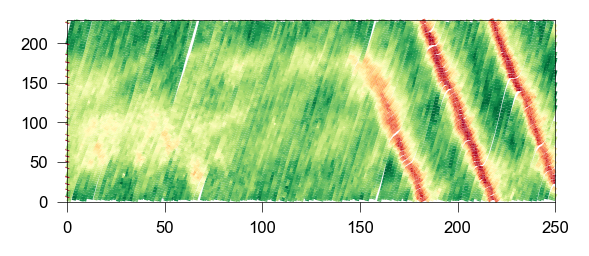

In [24]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(8 * params.cm, 3 * params.cm), dpi=200)

for car_id in df.car_id.unique():
    vehicle_data = df[df.car_id == car_id]
    t_vals = []
    x_vals = []
    v_vals = []
    prev_x = None
    for t_i, x_i, v_i in zip(
        vehicle_data.time.to_numpy(),
        (vehicle_data.position.to_numpy()),
        vehicle_data.velocity.to_numpy(),
    ):
        if prev_x is not None and abs(x_i - prev_x) > 0.5 * road_length:
            t_vals.append(t_i)
            x_vals.append(np.nan)
            v_vals.append(np.nan)

        t_vals.append(t_i)
        x_vals.append(x_i)
        v_vals.append(v_i)
        prev_x = x_i

    t_vals = np.asarray(t_vals, dtype=float)
    x_vals = np.asarray(x_vals, dtype=float)
    #v_vals = np.asarray(v_vals, dtype=float)

    #ax.plot(t_vals, x_vals, c="k", lw=0.5)

    colored_line(
        t_vals,
        x_vals,
        v_vals,
        ax=ax,
        cmap=cmap,
        #linewidth=1.5,
        clip_on=False,
        zorder=-1,
    )
ax.set_xlim(0,t_vals[-1])
ax.set_ylim(0,road_length)
plt.show()

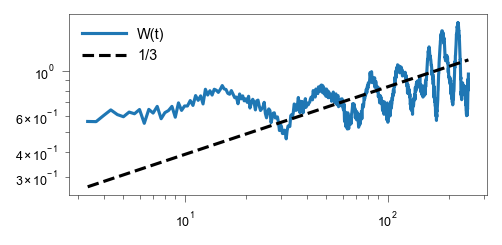

In [25]:
# Assume W_series is already computed and has shape (T,)

start = 10
fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=150)
names = []
ax.set_aspect("equal")
# for W, timestamps, letter in zip(l_W, l_timestamps, letters):
W_late = W[start:]  # take late-time part
t = timestamps[start:]  # np.arange(start, start + len(W_late))  # corresponding time steps

plt.loglog(t, W_late, label=f"W(t)")  # , c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t))
ref_line = np.exp(logA) * t ** (1 / 3)
plt.loglog(t, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

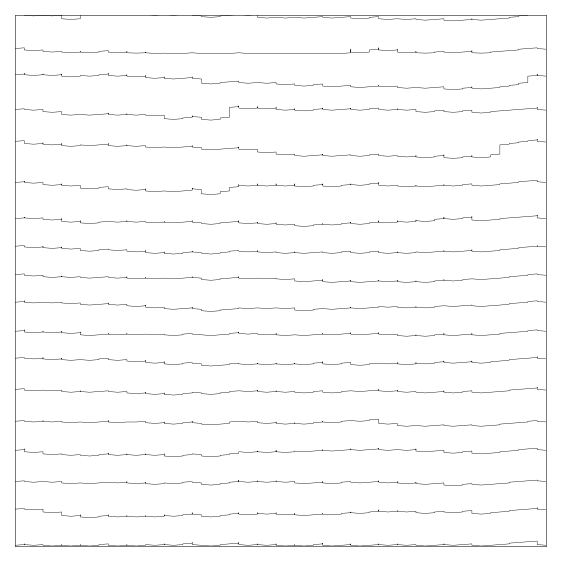

In [26]:
fig, ax = plt.subplots(figsize=(9 * params.cm, 9 * params.cm), dpi=150)

# Assuming N_fluct is a 2D array
# Create coordinate grids for plotting
y = np.arange(N.shape[0])
x = np.arange(N.shape[1])
X, Y = np.meshgrid(x, y)

# Plot black contours
# Number of contour levels you want
num_contours = 20  # <-- change this to control number of contours

# Plot contours
contours = ax.contour(
    X,
    Y,
    N,  # your array (negated if needed)
    levels=num_contours,  # number of contour levels
    colors="black",  # black lines
    linewidths=0.2,  # line width
)
# ax.set_title("Contour Plot of N_fluct")
# Remove all ticks and numbers
ax.set_xticks([])  # remove x-axis ticks
ax.set_yticks([])  # remove y-axis ticks
ax.set_xticklabels([])  # remove x-axis labels
ax.set_yticklabels([])  # remove y-axis labels
plt.tight_layout(pad=0)
plt.show()

In [27]:
l_W = []
l_timestamps = []
l_L = []

road_length = 260
letters = ["A", "B", "C", "D", "E", "F", "G"]
letters = [
    "G",
    "D",
]
for letter in letters:
    # path to one ARED trajectory file
    file_path = f"./input/ARED/exp{letter}.csv"

    df = pd.read_csv(file_path)
    id_order = df.loc[df.timestamp == 0].sort_values("cam_distance").veh_id.to_numpy()
    L = len(id_order)
    dt = df.timestamp.diff().unique()[1]
    timestamps = np.sort(df.timestamp.unique())

    velocities = (
        df.pivot(index="timestamp", columns="veh_id", values="cam_velocity")
        .reindex(index=timestamps, columns=id_order)
        .to_numpy()
    )
    distances = (
        df.pivot(index="timestamp", columns="veh_id", values="cam_distance")
        .reindex(index=timestamps, columns=id_order)
        .to_numpy()
        % road_length
    )
    spacings = (np.roll(distances, -1, axis=1) - distances) % road_length
    # N = newell_surface(velocities, spacings, dt)
    # W = interface_width_series(N)

    _, N = eulerian_surface_from_passages(
        positions=distances,
        # timestamps=timestamps,
        L=road_length,
        dx=9,
    )
    W = interface_width_series(N)
    l_L.append(L)
    l_W.append(W)
    l_timestamps.append(timestamps)
    print(dt)
    # print(df.columns)

0.0333333333333333
0.0333333333333333


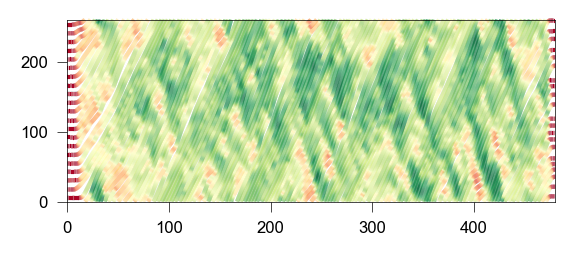

In [28]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(8 * params.cm, 3 * params.cm), dpi=200)

for veh_id in id_order:
    vehicle_data = df[df.veh_id == veh_id]
    t_vals = []
    x_vals = []
    v_vals = []
    prev_x = None
    for t_i, x_i, v_i in zip(
        vehicle_data.timestamp.to_numpy(),
        (vehicle_data.cam_distance.to_numpy() % road_length).astype(float),
        vehicle_data.cam_velocity.to_numpy(),
    ):
        if prev_x is not None and abs(x_i - prev_x) > 0.5 * road_length:
            t_vals.append(t_i)
            x_vals.append(np.nan)
            v_vals.append(np.nan)

        t_vals.append(t_i)
        x_vals.append(x_i)
        v_vals.append(v_i)
        prev_x = x_i

    t_vals = np.asarray(t_vals, dtype=float)
    x_vals = np.asarray(x_vals, dtype=float)
    v_vals = np.asarray(v_vals, dtype=float)

    #ax.plot(t_vals, x_vals, c="k", lw=0.5)

    colored_line(
        t_vals,
        x_vals,
        v_vals,
        ax=ax,
        cmap=cmap,
        #linewidth=1.5,
        clip_on=False,
        zorder=-1,
    )
ax.set_xlim(0,t_vals[-1])
ax.set_ylim(0,road_length)
plt.show()

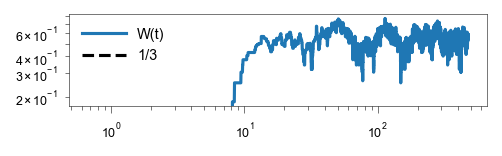

In [29]:
# Assume W_series is already computed and has shape (T,)

start = 20
fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=150)
names = []
ax.set_aspect("equal")
# for W, timestamps, letter in zip(l_W, l_timestamps, letters):
W_late = W[start:]  # take late-time part
t = timestamps[start:]  # np.arange(start, start + len(W_late))  # corresponding time steps

plt.loglog(t, W_late, label=f"W(t)")  # , c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t))
ref_line = np.exp(logA) * t ** (1 / 3)
plt.loglog(t, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

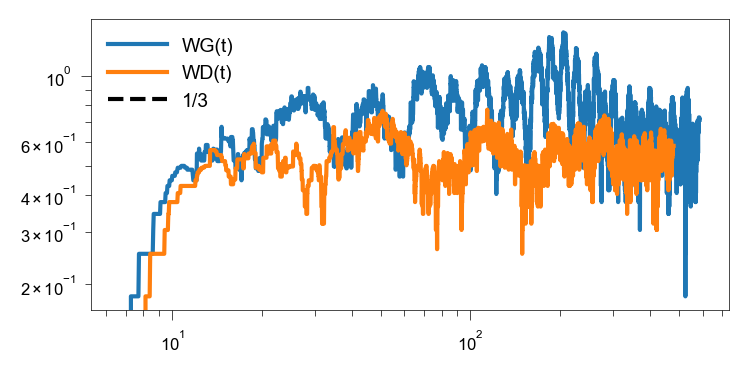

In [30]:
# Assume W_series is already computed and has shape (T,)

start = 200
fig, ax = plt.subplots(figsize=(9 * params.cm, 8 * params.cm), dpi=200)
names = []
ax.set_aspect("equal")
for W, timestamps, letter in zip(l_W, l_timestamps, letters):
    W_late = W[start:]  # take late-time part
    t = timestamps[start:]  # np.arange(start, start + len(W_late))  # corresponding time steps

    plt.loglog(t, W_late, label=f"W{letter}(t)")  # , c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t))
ref_line = np.exp(logA) * t ** (1 / 3)
plt.loglog(t, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()